<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/ND_Bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. KONFİGÜRASYONLAR (Veri yapılarını ayrı tutuyoruz)
CONFIG_CN = {
    "kategori": "CN",
    "kaynak": '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/nifti_dataset/nifti_CN',
    "hedef": '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/n4_corrected/n4_CN'
}


In [ ]:
CONFIG_EMCI = {
    "kategori": "EMCI",
    "kaynak": '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/nifti_dataset/nifti_EMCI',
    "hedef": '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/n4_corrected/n4_EMCI'
}

In [ ]:

!pip install antspyx -q

In [ ]:
import ants
import os


def n4_duzeltme_uygula(config):
    """
    Verilen konfigürasyondaki NIfTI dosyalarına N4 Bias Correction uygular.
    Daha önce işlenen dosyaları sayar ve raporlar.
    """
    kaynak = config["kaynak"]
    hedef = config["hedef"]
    etiket = config["kategori"]

    atlanan_sayac = 0  # Daha önce işlenenleri saymak için

    print(f"\n {etiket} grubu için N4 işlemi başlatılıyor...")

    if not os.path.exists(hedef):
        os.makedirs(hedef)

    dosyalar = sorted([f for f in os.listdir(kaynak) if f.endswith(".nii.gz") and "_bet" not in f])
    toplam = len(dosyalar)

    for i, ad in enumerate(dosyalar, 1):
        girdi_yolu = os.path.join(kaynak, ad)
        cikti_yolu = os.path.join(hedef, ad)

        # Dosya zaten varsa sayacı artır ve atla
        if os.path.exists(cikti_yolu):
            atlanan_sayac += 1
            continue

        try:
            img = ants.image_read(girdi_yolu)
            img_n4 = ants.n4_bias_field_correction(img)
            ants.image_write(img_n4, cikti_yolu)
            print(f"[{i}/{toplam}] İşlendi: {ad}")

        except Exception as e:
            print(f" Hata ({ad}): {str(e)}")

    # Final raporu
    print(f"\n {etiket} Özet Raporu:")
    print(f" Yeni İşlenen Dosya: {toplam - atlanan_sayac}")
    print(f" Atlanan (Zaten Mevcut): {atlanan_sayac}")
    print(f" {etiket} grubu başarıyla tamamlandı.")

In [ ]:
# Önce CN grubunu çalıştırır
n4_duzeltme_uygula(CONFIG_CN)


 CN grubu için N4 işlemi başlatılıyor...

 CN Özet Raporu:
 Yeni İşlenen Dosya: 0
 Atlanan (Zaten Mevcut): 30
 CN grubu başarıyla tamamlandı.


In [ ]:
 #Ardından EMCI grubunu çalıştırır
n4_duzeltme_uygula(CONFIG_EMCI)


 EMCI grubu için N4 işlemi başlatılıyor...

 EMCI Özet Raporu:
 Yeni İşlenen Dosya: 0
 Atlanan (Zaten Mevcut): 30
 EMCI grubu başarıyla tamamlandı.


🎲 Rastgele Seçilen (CN): 012_S_1133.nii.gz


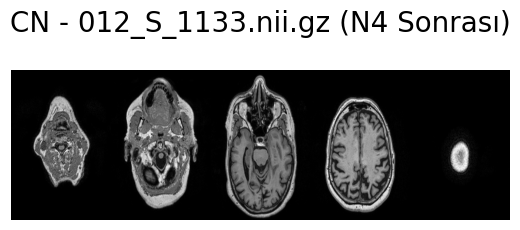

🎲 Rastgele Seçilen (EMCI): 099_S_2146.nii.gz


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


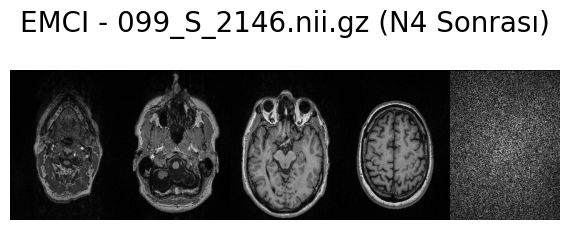

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import ants
import os
import random
import matplotlib.pyplot as plt

def rastgele_vaka_goster(config):
    """
    Hedef klasörden rastgele bir NIfTI dosyası seçer ve
    merkezi kesitlerini (Axial, Sagittal, Coronal) görselleştirir.
    """
    hedef_yol = config["hedef"]
    kategori = config["kategori"]

    # Klasördeki dosyaları listele
    dosyalar = [f for f in os.listdir(hedef_yol) if f.endswith(".nii.gz")]

    if not dosyalar:
        print(f"⚠️ Uyarı: {hedef_yol} klasöründe dosya bulunamadı!")
        return

    # Rastgele bir dosya seç [cite: 2026-03-05]
    secilen_dosya = random.choice(dosyalar)
    tam_yol = os.path.join(hedef_yol, secilen_dosya)

    print(f"🎲 Rastgele Seçilen ({kategori}): {secilen_dosya}")

    # Görüntüyü oku [cite: 2026-03-05]
    img = ants.image_read(tam_yol)

    # ANTs'in kendi plot fonksiyonu ile hızlıca görselleştirme [cite: 2026-03-05]
    # 'axis=2' axial kesitleri, 'nslices=5' ise 5 farklı seviyeyi gösterir.
    # Sen 5 kesitli veriyle çalıştığın için nslices=5 tam senin verine uygundur.
    ants.plot(img, axis=2, nslices=5, title=f"{kategori} - {secilen_dosya} (N4 Sonrası)")

# --- ÇALIŞTIR ---
# İstediğin kategoriyi buraya yazarak ayrı ayrı çağırabilirsin
rastgele_vaka_goster(CONFIG_CN)
rastgele_vaka_goster(CONFIG_EMCI)